# AutoSort Evaluation Pipeline

Main steps:
1. Load data (same as training)
2. Prepare evaluation data for each time segment
3. Load models and evaluate for each clique and time segment


In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')
import os
import gc
import torch
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
from spikeinterface.core import concatenate_recordings
from probeinterface import write_probeinterface, read_probeinterface
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from utils_clique import (
    prepare_training_data,
    evaluate_autosort_model,
    build_sliding_cliques,
    CliqueInfo,
    visualize_umap_features,
    calibration_model,
    calibration_model_no_whiten,
    real_time_processing,
    generate_confusion_matrix_df,
    compute_noise_detection_metrics,
    match_neurons,
    SimpleAutoSort,
    SimpleWaveformLoader,
    detect_spike_no_whiten
)


In [2]:
# Channel list (same as training)
channel_list_A = ['A-000', 'A-001', 'A-002',
       'A-003', 'A-004', 'A-005', 'A-006', 'A-007', 'A-008', 'A-009',
       'A-010', 'A-011', 'A-012', 'A-013', 'A-014', 'A-015', 'A-016',
       'A-017', 'A-018', 'A-019', 'A-020', 'A-021', 'A-022', 'A-023',
       'A-024', 'A-025', 'A-026', 'A-027', 'A-028', 'A-029', 'A-030',
       'A-031', 'A-032', 'A-033', 'A-034', 'A-035', 'A-036', 'A-037',
       'A-038', 'A-039', 'A-040', 'A-041', 'A-042', 'A-043', 'A-044',
       'A-045', 'A-046', 'A-047', 'A-048', 'A-049', 'A-050', 'A-051',
       'A-052', 'A-053', 'A-054', 'A-055', 'A-056', 'A-057', 'A-058',
       'A-059', 'A-060', 'A-061', 'A-062', 'A-063', 'A-064', 'A-065',
       'A-066', 'A-067', 'A-068', 'A-069', 'A-070', 'A-071', 'A-072',
       'A-073', 'A-074', 'A-075', 'A-076', 'A-077', 'A-078', 'A-079',
       'A-080', 'A-081', 'A-082', 'A-083', 'A-084', 'A-085', 'A-086',
       'A-087', 'A-088', 'A-089', 'A-090', 'A-091', 'A-092', 'A-093',
       'A-094', 'A-095', 'A-096', 'A-097', 'A-098', 'A-099', 'A-100',
       'A-101', 'A-102', 'A-103', 'A-104', 'A-105', 'A-106', 'A-107',
       'A-108', 'A-109', 'A-110', 'A-111', 'A-112', 'A-113', 'A-114',
       'A-115', 'A-116', 'A-117', 'A-118', 'A-119', 'A-120', 'A-121',
       'A-122', 'A-123', 'A-124', 'A-125', 'A-126', 'A-127']

channel_list = ['B-000', 'B-001', 'B-002',
       'B-003', 'B-004', 'B-005', 'B-006', 'B-007', 'B-008', 'B-009',
       'B-010', 'B-011', 'B-012', 'B-013', 'B-014', 'B-015', 'B-016',
       'B-017', 'B-018', 'B-019', 'B-020', 'B-021', 'B-022', 'B-023',
       'B-024', 'B-025', 'B-026', 'B-027', 'B-028', 'B-029', 'B-030',
       'B-031', 'B-032', 'B-033', 'B-034', 'B-035', 'B-036', 'B-037',
       'B-038', 'B-039', 'B-040', 'B-041', 'B-042', 'B-043', 'B-044',
       'B-045', 'B-046', 'B-047', 'B-048', 'B-049', 'B-050', 'B-051',
       'B-052', 'B-053', 'B-054', 'B-055', 'B-056', 'B-057', 'B-058',
       'B-059', 'B-060', 'B-061', 'B-062', 'B-063', 'B-064', 'B-065',
       'B-066', 'B-067', 'B-068', 'B-069', 'B-070', 'B-071', 'B-072',
       'B-073', 'B-074', 'B-075', 'B-076', 'B-077', 'B-078', 'B-079',
       'B-080', 'B-081', 'B-082', 'B-083', 'B-084', 'B-085', 'B-086',
       'B-087', 'B-088', 'B-089', 'B-090', 'B-091', 'B-092', 'B-093',
       'B-094', 'B-095', 'B-096', 'B-097', 'B-098', 'B-099', 'B-100',
       'B-101', 'B-102', 'B-103', 'B-104', 'B-105', 'B-106', 'B-107',
       'B-108', 'B-109', 'B-110', 'B-111', 'B-112', 'B-113', 'B-114',
       'B-115', 'B-116', 'B-117', 'B-118', 'B-119', 'B-120', 'B-121',
       'B-122', 'B-123', 'B-124', 'B-125', 'B-126', 'B-127']

In [3]:
spike_inf_path = "/media/ubuntu/sda/mouse_test/sorted/mouse_1/20251215/spike_inf.tsv"
neuron_inf_path = "/media/ubuntu/sda/mouse_test/sorted/mouse_1/20251215/neuron_inf.pkl"

recording_path = Path(f"/media/ubuntu/sda/mouse_test/raw_data/WLF_128ch2mouse1_natima_251215_232216")
rhd_files = list(recording_path.glob("*.rhd"))

file_list = sorted(rhd_files)
recording_raw_list = []
for file in file_list:
    recording_raw_list.append(se.read_intan(file, stream_id= '0'))
recording_raw = concatenate_recordings(recording_list=recording_raw_list)

In [4]:
recording_raw = recording_raw.select_channels(channel_list)
recording_raw = spre.unsigned_to_signed(recording_raw)
recording_raw = spre.resample(recording_raw, 10000)
recording_recorded = spre.bandpass_filter(recording_raw, freq_min=300, freq_max=3000)
recording_recorded = spre.notch_filter(recording_recorded, freq=50)
recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")

In [5]:

probe = read_probeinterface('/media/ubuntu/sda/mouse_test/probe/tip_probe_128_1.json')
if probe is None:
    raise ValueError("Recording does not have probe information")

# 定义按shank构建cliques的函数（same as training）
def build_shank_cliques(probe, shank_boundaries=[250, 750, 1250]):
    """
    根据x坐标划分shank并构建cliques
    
    Parameters:
        probe: Probe对象
        shank_boundaries: shank之间的x坐标边界，默认[250, 750, 1250]
                         将probe划分为4个shank:
                         - shank 0: x < 250
                         - shank 1: 250 <= x < 750
                         - shank 2: 750 <= x < 1250
                         - shank 3: x >= 1250
    
    Returns:
        cliques: List[CliqueInfo] - 每个shank对应一个clique
    """
    from typing import List
    
    df = probe.to_dataframe()
    if "device_channel_indices" in df.columns:
        device_indices = df["device_channel_indices"].astype(int).to_numpy()
    else:
        device_indices = np.arange(len(df), dtype=int)
    positions = df.loc[:, ["x", "y"]].to_numpy()
    contact_ids = df["contact_ids"].astype(str).to_numpy()
    
    # 根据x坐标划分shank
    x_coords = positions[:, 0]
    shank_boundaries_sorted = sorted(shank_boundaries)
    
    cliques: List[CliqueInfo] = []
    
    # 定义shank范围
    shank_ranges = [
        (float('-inf'), shank_boundaries_sorted[0]),  # shank 0: x < 250
        (shank_boundaries_sorted[0], shank_boundaries_sorted[1]),  # shank 1: 250 <= x < 750
        (shank_boundaries_sorted[1], shank_boundaries_sorted[2]),  # shank 2: 750 <= x < 1250
        (shank_boundaries_sorted[2], float('inf')),  # shank 3: x >= 1250
    ]
    
    for shank_id, (x_min, x_max) in enumerate(shank_ranges):
        # 找到属于当前shank的通道
        if x_min == float('-inf'):
            mask = x_coords < x_max
        elif x_max == float('inf'):
            mask = x_coords >= x_min
        else:
            mask = (x_coords >= x_min) & (x_coords < x_max)
        
        shank_device_indices = device_indices[mask]
        shank_contact_ids = contact_ids[mask]
        shank_positions = positions[mask]
        
        if len(shank_device_indices) == 0:
            print(f"[WARNING] Shank {shank_id} has no channels")
            continue
        
        # 计算shank的中心位置
        center = tuple(np.mean(shank_positions, axis=0))
        
        # 创建CliqueInfo对象
        clique = CliqueInfo(
            clique_id=shank_id,
            device_channel_indices=list(shank_device_indices),
            contact_ids=list(shank_contact_ids),
            center=center,
        )
        cliques.append(clique)
        
        print(f"[INFO] Shank {shank_id}: {len(shank_device_indices)} channels "
              f"(x range: {x_min if x_min != float('-inf') else 'min'} to "
              f"{x_max if x_max != float('inf') else 'max'})")
    
    print(f"[INFO] Built {len(cliques)} cliques from {len(shank_boundaries) + 1} shanks")
    return cliques

# Build cliques from probe by shank (same as training)
cliques = build_shank_cliques(probe, shank_boundaries=[250, 750, 1250])

# Load clique information (saved during training)
base_save_dir = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output"
clique_info_path = Path(base_save_dir) / "clique_info.pkl"

if clique_info_path.exists():
    with open(clique_info_path, 'rb') as f:
        clique_info = pickle.load(f)
    # Use cliques from saved file if available, otherwise use the ones we just built
    if 'cliques' in clique_info:
        cliques = clique_info['cliques']
        print(f"Loaded {len(cliques)} cliques from {clique_info_path}")
    else:
        print(f"Using built cliques: {len(cliques)} cliques")
else:
    print(f"Clique info not found at {clique_info_path}, using built cliques: {len(cliques)} cliques")

# Load GT data (evaluation data)
spike_inf = None
neuron_inf = None

if Path(spike_inf_path).exists():
    spike_inf = pd.read_csv(spike_inf_path, sep='\t', index_col=0)
else:
    raise ValueError(f"spike_inf not found at {spike_inf_path}")

if Path(neuron_inf_path).exists():
    with open(neuron_inf_path, 'rb') as f:
        neuron_inf = pickle.load(f)
else:
    raise ValueError(f"neuron_inf.pkl not found at {neuron_inf_path}")

# Load training data neuron_inf (for calibration matching)
# Training data path (same recording as training, but different session)
train_neuron_inf_path = "/media/ubuntu/sda/mouse_test/sorted/mouse_1/20251217/neuron_inf.pkl"
train_neuron_inf = None

if Path(train_neuron_inf_path).exists():
    with open(train_neuron_inf_path, 'rb') as f:
        train_neuron_inf = pickle.load(f)
    print(f"Training neuron_inf loaded from: {train_neuron_inf_path}")
    print(f"  Number of training neurons: {len(train_neuron_inf)}")
else:
    print(f"Warning: Training neuron_inf not found at {train_neuron_inf_path}")
    print(f"  Will use evaluation neuron_inf as fallback (may not have position/waveform info)")

print(f"\nRecording loaded successfully")
print(f"Sampling rate: {recording_f.get_sampling_frequency()} Hz")
print(f"Number of channels: {recording_f.get_num_channels()}")
print(f"Recording duration: {recording_f.get_num_samples() / recording_f.get_sampling_frequency():.2f} seconds")


[INFO] Shank 0: 32 channels (x range: min to 250)
[INFO] Shank 1: 32 channels (x range: 250 to 750)
[INFO] Shank 2: 32 channels (x range: 750 to 1250)
[INFO] Shank 3: 32 channels (x range: 1250 to max)
[INFO] Built 4 cliques from 4 shanks
Loaded 4 cliques from /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128_20251221/output/clique_info.pkl
Training neuron_inf loaded from: /media/ubuntu/sda/mouse_test/sorted/mouse_1/20251217/neuron_inf.pkl
  Number of training neurons: 42

Recording loaded successfully
Sampling rate: 10000.0 Hz
Number of channels: 128
Recording duration: 1862.71 seconds


In [6]:
# Step 2.5: Match neurons between training and evaluation data
# This establishes the mapping between training set neurons and evaluation set neurons
# based on position and waveform similarity

print(f"\n{'='*80}")
print(f"Step 2.5: Neuron Matching (Training Set <-> Evaluation Set)")
print(f"{'='*80}")

# Check if neuron_inf has required columns for matching
required_cols = ['position_1', 'position_2', 'position_waveform']
train_has_cols = all(col in train_neuron_inf.columns for col in required_cols) if train_neuron_inf is not None else False
eval_has_cols = all(col in neuron_inf.columns for col in required_cols)

if train_has_cols and eval_has_cols and train_neuron_inf is not None:
    # Perform neuron matching
    eval_neuron_inf_matched = match_neurons(
        train_neuron_inf=train_neuron_inf,
        eval_neuron_inf=neuron_inf,
        position_threshold=10,
        waveform_similarity_threshold=0.95
    )
    
    # Count matched and unmatched neurons
    matched_neurons = eval_neuron_inf_matched[eval_neuron_inf_matched['neuron_match'] != 'unmatch']
    unmatched_neurons = eval_neuron_inf_matched[eval_neuron_inf_matched['neuron_match'] == 'unmatch']
    
    print(f"\nMatching Summary:")
    print(f"  - Total evaluation neurons: {len(eval_neuron_inf_matched)}")
    print(f"  - Matched neurons: {len(matched_neurons)}")
    print(f"  - Unmatched neurons: {len(unmatched_neurons)}")
    
    if len(matched_neurons) > 0:
        print(f"  - Matched neuron pairs (first 5):")
        for idx, row in matched_neurons.head(5).iterrows():
            print(f"    {row['Neuron']} -> {row['neuron_match']}")
    
    if len(unmatched_neurons) > 0:
        print(f"  - Unmatched neuron names: {unmatched_neurons['Neuron'].tolist()}")
    
    # Use matched neuron_inf for subsequent processing
    neuron_inf = eval_neuron_inf_matched
    print(f"\n  ✓ Using matched neuron_inf for calibration and evaluation")
    print(f"  ✓ GT label mapping will be established using neuron_match column")
else:
    print(f"Warning: Missing required columns or training neuron_inf for neuron matching")
    if train_neuron_inf is None:
        print(f"  - Training neuron_inf is None")
    else:
        print(f"  - Training neuron_inf has required columns: {train_has_cols}")
    print(f"  - Evaluation neuron_inf has required columns: {eval_has_cols}")
    print(f"  - Required columns: {required_cols}")
    print(f"  - Will proceed without matching (neuron_match column will not be available)")
    print(f"  - Note: GT label mapping may not be established correctly")



Step 2.5: Neuron Matching (Training Set <-> Evaluation Set)
Neuron Matching
Matching neurons...
  Neuron_35 -> Neuron_30 (Similarity: 0.9997, Position distance: 7.67)
  Neuron_70 -> Neuron_174 (Similarity: 0.9960, Position distance: 0.96)
  Neuron_71 -> Neuron_66 (Similarity: 0.9947, Position distance: 1.62)
  Neuron_83 -> Neuron_80 (Similarity: 0.9946, Position distance: 0.81)
  Neuron_90 -> Neuron_88 (Similarity: 0.9960, Position distance: 6.90)
  Neuron_92 -> Neuron_94 (Similarity: 0.9874, Position distance: 4.72)
  Neuron_99 -> Neuron_94 (Similarity: 0.9626, Position distance: 3.57)
  Neuron_101 -> Neuron_198 (Similarity: 0.9868, Position distance: 1.97)
  Neuron_134 -> Neuron_170 (Similarity: 0.9909, Position distance: 8.63)
  Neuron_136 -> Neuron_182 (Similarity: 0.9820, Position distance: 5.18)
  Neuron_139 -> Neuron_144 (Similarity: 0.9934, Position distance: 2.27)
  Neuron_147 -> Neuron_152 (Similarity: 0.9829, Position distance: 3.45)
  Neuron_155 -> Neuron_156 (Similarity: 

In [7]:
# Downsample train_neuron_inf position_waveform from 60 to 30 dimensions
# This is needed to match the system which uses 30-sample waveforms (left_sample=10, right_sample=20)
if train_neuron_inf is not None and 'position_waveform' in train_neuron_inf.columns:
    from scipy.signal import resample
    print(f"\nDownsampling train_neuron_inf position_waveform from 60 to 30 dimensions...")
    
    original_dims = []
    for idx, row in train_neuron_inf.iterrows():
        wf = row['position_waveform']
        if not isinstance(wf, np.ndarray):
            wf = np.array(wf)
        original_dims.append(len(wf))
    
    if len(original_dims) > 0:
        unique_dims = set(original_dims)
        print(f"  Original waveform dimensions: {unique_dims}")
        
        # Only downsample if waveforms are 60-dimensional
        if 60 in unique_dims:
            print(f"  Downsampling 60-dimensional waveforms to 30 dimensions...")
            for idx, row in train_neuron_inf.iterrows():
                wf = row['position_waveform']
                if not isinstance(wf, np.ndarray):
                    wf = np.array(wf)
                
                if len(wf) == 60:
                    # Resample from 60 to 30 samples
                    wf_downsampled = resample(wf, 30)
                    train_neuron_inf.at[idx, 'position_waveform'] = wf_downsampled
            
            # Verify downsampling
            new_dims = []
            for idx, row in train_neuron_inf.iterrows():
                wf = row['position_waveform']
                if not isinstance(wf, np.ndarray):
                    wf = np.array(wf)
                new_dims.append(len(wf))
            unique_new_dims = set(new_dims)
            print(f"  New waveform dimensions: {unique_new_dims}")
            print(f"  ✓ Downsampling completed")
        else:
            print(f"  No 60-dimensional waveforms found, skipping downsampling")
    else:
        print(f"  Warning: No waveforms found in train_neuron_inf")
else:
    print(f"Warning: train_neuron_inf is None or does not have 'position_waveform' column")


Downsampling train_neuron_inf position_waveform from 60 to 30 dimensions...
  Original waveform dimensions: {60}
  Downsampling 60-dimensional waveforms to 30 dimensions...
  New waveform dimensions: {30}
  ✓ Downsampling completed


In [8]:
# Convert spike_inf time indices from 20k to 10k sampling rate
# Since recording has been downsampled from 20k to 10k, spike_inf time indices need to be divided by 2
if spike_inf is not None and 'time' in spike_inf.columns:
    print(f"Converting spike_inf time indices from 20k to 10k sampling rate...")
    print(f"  Original time range: {spike_inf['time'].min()} - {spike_inf['time'].max()}")
    spike_inf['time'] = spike_inf['time'] / 2.0
    spike_inf['time'] = spike_inf['time'].astype(int)  # Convert to integer
    print(f"  Converted time range: {spike_inf['time'].min()} - {spike_inf['time'].max()}")
    print(f"  Total spikes: {len(spike_inf)}")
else:
    print("Warning: spike_inf is None or does not have 'time' column")

Converting spike_inf time indices from 20k to 10k sampling rate...
  Original time range: 20 - 37254088
  Converted time range: 10 - 18627044
  Total spikes: 1859402


In [9]:
# Parameters for calibration and real-time processing
calibration_duration_seconds = 200  # Calibration stage duration (first 60 seconds)
n_additional_clusters = 10  # Number of additional clusters for K-means
time_window_seconds = 10.0  # Real-time processing window size (seconds)
total_duration_seconds = None  # Total processing duration (None = process until end)

# No-whiten detection parameters (same as training)
no_whiten_params = {
    'thr_min': 2,
    'thr_max': 30,
    'distance': 3,
    'ch_max_simul_firing': 5,
    'wlen': 5,
    'prominence': 10,
}

# Window parameters (same as training)
window_params = {
    'left_sample': 10,
    'right_sample': 20,
}

# Calibration matching parameters
position_threshold = 10.0  # Position distance threshold (microns)
waveform_similarity_threshold = 0.95  # Waveform similarity threshold

# Number of training runs per clique
n_runs = 1

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Build device to recording channel mapping (same as training)
recording_channel_ids = recording_f.get_channel_ids()
probe_df = probe.to_dataframe()
if "device_channel_indices" in probe_df.columns:
    probe_device_indices = probe_df["device_channel_indices"].astype(int).to_numpy()
else:
    probe_device_indices = np.arange(len(probe_df), dtype=int)

device_to_recording_channel = {}
for i, device_idx in enumerate(probe_device_indices):
    if i < len(recording_channel_ids):
        device_to_recording_channel[device_idx] = recording_channel_ids[i]

print(f"\n{'='*80}")
print(f"Parameters:")
print(f"{'='*80}")
print(f"Calibration duration: {calibration_duration_seconds} seconds")
print(f"Number of additional clusters: {n_additional_clusters}")
print(f"Real-time processing window: {time_window_seconds} seconds")
print(f"Total processing duration: {total_duration_seconds if total_duration_seconds is not None else 'until end'}")
print(f"Number of runs per clique: {n_runs}")
print(f"{'='*80}")


Using device: cuda

Parameters:
Calibration duration: 200 seconds
Number of additional clusters: 10
Real-time processing window: 10.0 seconds
Total processing duration: until end
Number of runs per clique: 1


In [10]:
# Store all calibration and real-time processing results
all_calibration_results = {}  # {clique_id: {run_id: calibration_results}}
all_processing_results = {}  # {clique_id: {run_id: processing_results}}

# Process each clique
for clique_id in range(len(cliques)):
    print(f"\n{'='*80}")
    print(f"Processing Clique {clique_id:02d}")
    print(f"{'='*80}")

    
    clique = cliques[clique_id]
    n_channels = len(clique.device_channel_indices)
    
    # Map device indices to recording channel IDs (same as training)
    clique_device_indices = set(clique.device_channel_indices)
    sorted_device_indices = sorted(clique_device_indices)
    clique_channel_ids = [device_to_recording_channel[idx] for idx in sorted_device_indices if idx in device_to_recording_channel]
    
    # Create recording_clique (subset of channels for this clique)
    recording_clique = recording_f.select_channels(channel_ids=clique_channel_ids)
    recording_clique = recording_clique.rename_channels(sorted_device_indices)
    
    # Debug: Check recording_clique duration
    sampling_rate = recording_clique.get_sampling_frequency()
    total_samples = recording_clique.get_num_samples()
    total_seconds = total_samples / sampling_rate
    print(f"  Recording_clique duration: {total_samples} samples ({total_seconds:.2f} seconds)")
    print(f"  Expected for calibration: {int(calibration_duration_seconds * sampling_rate)} samples ({calibration_duration_seconds} seconds)")
    
    # Filter GT data for this clique
    # Get neurons that have channels fully inside this clique (best_channels -> channel_id -> tract_channel fallback)
    neuron_inf_clique_list = []
    import ast
    for _, row in neuron_inf.iterrows():
        channels = row.get('best_channels', [])
        if isinstance(channels, str):
            try:
                channels = ast.literal_eval(channels)
            except Exception:
                channels = []
        if not isinstance(channels, (list, tuple, np.ndarray)) or len(channels) == 0:
            channels = row.get('channel_id', [])
            if isinstance(channels, str):
                try:
                    channels = ast.literal_eval(channels)
                except Exception:
                    channels = []
            if not isinstance(channels, (list, tuple, np.ndarray)) or len(channels) == 0:
                if 'tract_channel' in row:
                    tract_ch = row.get('tract_channel', None)
                    if pd.notna(tract_ch) and tract_ch is not None:
                        channels = [int(tract_ch)]
                else:
                    channels = []
        channels_set = set(channels)
        if len(channels_set) == 0:
            continue
        if channels_set.issubset(clique_device_indices):
            neuron_inf_clique_list.append(row)
    neuron_inf_clique = pd.DataFrame(neuron_inf_clique_list).reset_index(drop=True)
    
    # Filter spike_inf accordingly (only spikes whose neuron/cluster in neuron_inf_clique)
    spike_inf_clique = spike_inf.copy()
    clique_neuron_names = set(neuron_inf_clique['Neuron'].unique()) if len(neuron_inf_clique) > 0 else set()
    if 'neuron' in spike_inf_clique.columns:
        spike_inf_clique = spike_inf_clique[spike_inf_clique['neuron'].isin(clique_neuron_names)].copy()
    elif 'cluster' in spike_inf_clique.columns:
        spike_inf_clique = spike_inf_clique[spike_inf_clique['cluster'].isin(clique_neuron_names)].copy()
    else:
        raise ValueError("spike_inf must have either 'neuron' or 'cluster' column")
    
    all_calibration_results[clique_id] = {}
    all_processing_results[clique_id] = {}
    
    # Process each training run
    for run_id in range(1, n_runs + 1):
        print(f"\n{'-'*60}")
        print(f"Clique {clique_id:02d} - Run {run_id}/{n_runs}")
        print(f"{'-'*60}")
        
        # Model save directory for this clique and run
        model_save_dir = Path(base_save_dir) / f"clique_{clique_id:02d}" / "model_save" / f"run_{run_id}"
        
        if not model_save_dir.exists():
            print(f"  Model not found at {model_save_dir}, skipping...")
            continue
        
        try:
            # Load model
            print(f"  Loading model...")
            train_data_dir = Path(base_save_dir) / f"clique_{clique_id:02d}" / "train_data"
            
            # Load keep_id
            keep_id_path = model_save_dir / 'keep_id.pkl'
            if not keep_id_path.exists():
                print(f"  Warning: keep_id.pkl not found, skipping...")
                continue
            
            with open(keep_id_path, 'rb') as f:
                keep_id = pickle.load(f)
            
            # Create dataset to get weights (for model initialization)
            dataset = SimpleWaveformLoader(
                root=str(train_data_dir) + '/',
                shank_channel=np.arange(n_channels),
                Keep_id=keep_id
            )
            
            # Create model
            autosort_model = SimpleAutoSort(
                ch_num=n_channels,
                samplepoints=window_params['left_sample'] + window_params['right_sample'],
                device=device,
                set_shank_id=keep_id,
                save_dir=str(model_save_dir) + "/",
                pos_weight_noise=dataset.pos_weight_noise.to(device),
                pos_weight_label=dataset.pos_weight_label.to(device)
            )
            
            # Load model weights
            autosort_model.load_model()
            autosort_model.eval()
            
            # Load training neuron_inf (for calibration matching)
            # Get neurons from training data neuron_mapping (these are the neurons for this clique)
            train_data_dir = Path(base_save_dir) / f"clique_{clique_id:02d}" / "train_data"
            neuron_mapping_path = train_data_dir / "neuron_mapping.pkl"
            
            if neuron_mapping_path.exists():
                with open(neuron_mapping_path, 'rb') as f:
                    train_neuron_mapping = pickle.load(f)
                train_neuron_list = train_neuron_mapping.get('unique_neurons', [])
                print(f"  Training data has {len(train_neuron_list)} neurons for this clique")
                
                # Filter train_neuron_inf to only include neurons in this clique
                if train_neuron_inf is not None:
                    # Filter train_neuron_inf to only include neurons in train_neuron_list
                    train_neuron_inf_clique = train_neuron_inf[
                        train_neuron_inf['Neuron'].isin(train_neuron_list)
                    ].copy()
                    # 进一步过滤：仅保留 best_channels（或 fallback）全部落在本 clique 的 neuron
                    filtered_rows = []
                    import ast
                    for _, r in train_neuron_inf_clique.iterrows():
                        chs = r.get('best_channels', [])
                        if isinstance(chs, str):
                            try:
                                chs = ast.literal_eval(chs)
                            except Exception:
                                chs = []
                        if not isinstance(chs, (list, tuple, np.ndarray)) or len(chs) == 0:
                            chs = r.get('channel_id', [])
                            if isinstance(chs, str):
                                try:
                                    chs = ast.literal_eval(chs)
                                except Exception:
                                    chs = []
                            if not isinstance(chs, (list, tuple, np.ndarray)) or len(chs) == 0:
                                if 'tract_channel' in r:
                                    trc = r.get('tract_channel', None)
                                    if pd.notna(trc) and trc is not None:
                                        chs = [int(trc)]
                                else:
                                    chs = []
                        chs_set = set(chs)
                        if len(chs_set) > 0 and chs_set.issubset(clique_device_indices):
                            filtered_rows.append(r)
                    train_neuron_inf_clique = pd.DataFrame(filtered_rows).reset_index(drop=True)
                    print(f"  Filtered training neuron_inf: {len(train_neuron_inf_clique)} neurons (from {len(train_neuron_inf)} total)")
                    
                    if len(train_neuron_inf_clique) == 0:
                        print(f"  Warning: No matching neurons found in train_neuron_inf, using eval neuron_inf as fallback")
                        train_neuron_inf_clique = neuron_inf_clique.copy()
                else:
                    # Fallback: use eval neuron_inf (may not have position/waveform info)
                    print(f"  Warning: train_neuron_inf not available, using evaluation neuron_inf as fallback")
                    train_neuron_inf_clique = neuron_inf_clique.copy()
            else:
                # Fallback: use eval neuron_inf (may not have position/waveform info)
                print(f"  Warning: neuron_mapping.pkl not found, using evaluation neuron_inf as fallback")
                train_neuron_inf_clique = neuron_inf_clique.copy()
            
            # Calculate valid_channels: union of all tract_channel for TRAINING SET neurons in this clique
            # IMPORTANT: valid_channels should be based on training set neurons' tract_channel, not best_channels or channel_id
            # This ensures detection is only performed on channels where the model was trained to detect spikes
            
            # Map probe device_channel_indices to clique channel indices
            probe_to_clique_index = {}
            for clique_idx, device_idx in enumerate(sorted_device_indices):
                probe_to_clique_index[device_idx] = clique_idx
            
            # Collect all tract_channel from TRAINING SET neurons in this clique
            all_tract_channels_clique_indices = set()
            
            # Use train_neuron_inf_clique (training set neurons) to calculate valid_channels
            if len(train_neuron_inf_clique) > 0:
                for idx, row in train_neuron_inf_clique.iterrows():
                    # Directly use tract_channel (not best_channels or channel_id)
                    if 'tract_channel' in row:
                        tract_ch = row.get('tract_channel', None)
                        if pd.notna(tract_ch) and tract_ch is not None:
                            try:
                                tract_ch_int = int(tract_ch)
                                # Check if tract_channel is in this clique
                                if tract_ch_int in clique_device_indices:
                                    # Map probe channel index to clique channel index
                                    if tract_ch_int in probe_to_clique_index:
                                        all_tract_channels_clique_indices.add(probe_to_clique_index[tract_ch_int])
                            except (ValueError, TypeError):
                                continue
                
                valid_channels = sorted(list(all_tract_channels_clique_indices)) if len(all_tract_channels_clique_indices) > 0 else None
                
            else:
                # Fallback: if no training set neurons available, use all channels (not ideal)
                print(f"  Warning: train_neuron_inf_clique is empty, cannot determine valid_channels from training set")
                print(f"  Will detect on all channels (this may not be optimal)")
                valid_channels = None
            
            # Set up evaluation results save directory
            eval_save_dir = model_save_dir / "eval"
            eval_save_dir.mkdir(parents=True, exist_ok=True)
            run_name = f"run_{run_id}"
            
            # Generate date string (optional, can be customized)
            from datetime import datetime
            date_str = datetime.now().strftime("%m%d%y")  # Format: MMDDYY
            
            calibration_results = calibration_model_no_whiten(
                recording_f=recording_clique,
                autosort_model=autosort_model,
                train_neuron_inf=train_neuron_inf_clique,
                probe=probe,  # Pass probe object directly (not from recording_f)
                calibration_duration_seconds=calibration_duration_seconds,
                n_additional_clusters=n_additional_clusters,
                thr_min=no_whiten_params['thr_min'],
                thr_max=no_whiten_params['thr_max'],
                distance=no_whiten_params['distance'],
                ch_max_simul_firing=no_whiten_params['ch_max_simul_firing'],
                wlen=no_whiten_params['wlen'],
                prominence=no_whiten_params['prominence'],
                window_params=window_params,
                position_threshold=position_threshold,
                waveform_similarity_threshold=waveform_similarity_threshold,
                eval_neuron_inf=neuron_inf_clique,
                eval_spike_inf=spike_inf_clique,
                valid_channels=valid_channels,
                device=device,
                save_eval_results=True,  # Enable saving evaluation results
                eval_save_dir=str(eval_save_dir),  # Save directory
                run_name=run_name,  # Run name
                train_data_dir=str(train_data_dir),  # Training data directory (not used, kept for compatibility)
                date_str=date_str,  # Date string for file naming
                skip_noise_classifier=False
            )
            
            all_calibration_results[clique_id][run_id] = calibration_results
            
            # Save calibration results
            calibration_save_path = model_save_dir / "calibration_results.pkl"
            with open(calibration_save_path, 'wb') as f:
                pickle.dump(calibration_results, f)
            print(f"  Calibration results saved to: {calibration_save_path}")
            
            gc.collect()
            torch.cuda.empty_cache()
            # # Stage 2: Real-time Processing
            # print(f"\n  {'='*50}")
            # print(f"  Stage 2: Real-time Processing")
            # print(f"  {'='*50}")
            
            # processing_results = real_time_processing(
            #     recording_f=recording_clique,
            #     autosort_model=autosort_model,
            #     calibration_results=calibration_results,
            #     start_time_seconds=calibration_duration_seconds,
            #     time_window_seconds=time_window_seconds,
            #     total_duration_seconds=total_duration_seconds,
            #     detect_threshold=mountainsort4_detection_params['detect_threshold'],
            #     detect_interval=mountainsort4_detection_params['detect_interval'],
            #     detect_sign=mountainsort4_detection_params['detect_sign'],
            #     margin=mountainsort4_detection_params['margin'],
            #     window_params=window_params,
            #     eval_neuron_inf=neuron_inf_clique,
            #     eval_spike_inf=spike_inf_clique,
            #     device=device,
            # )
            
            # all_processing_results[clique_id][run_id] = processing_results
            
            # # Save processing results
            # processing_save_path = model_save_dir / "real_time_processing_results.pkl"
            # with open(processing_save_path, 'wb') as f:
            #     pickle.dump(processing_results, f)
            # print(f"  Real-time processing results saved to: {processing_save_path}")
            
            # print(f"\n  Clique {clique_id:02d} - Run {run_id} completed!")
            
        except Exception as e:
            print(f"  Error processing clique {clique_id}, run {run_id}: {e}")
            import traceback
            traceback.print_exc()
        break



Processing Clique 00
  Recording_clique duration: 18627072 samples (1862.71 seconds)
  Expected for calibration: 2000000 samples (200 seconds)

------------------------------------------------------------
Clique 00 - Run 1/1
------------------------------------------------------------
  Loading model...
  Training data has 4 neurons for this clique
  Filtered training neuron_inf: 4 neurons (from 42 total)
Stage 1: Calibration (No-Whiten Method)
Loading first 200 seconds of data...

### 1. Load calibration data (no whitening)

### 2. Threshold detection (No-Whiten Method)
  thr_min: 2, thr_max: 30, distance: 3, prominence: 10
共 4 个通道
Number of detected spikes: 171062

### GT Spike Statistics:
  GT neurons: 3, GT spikes: 17313

### Detection Rate (after threshold detection): 0.8025 (13894/17313)

### 3. Extract waveforms (using original traces)
Number of valid spikes: 171060

### 4. Noise classifier filtering


Noise classification: 100%|██████████| 42/42 [00:00<00:00, 51.85it/s]


Number of spikes passing noise classifier: 46813

---Noise classifier analysis on matched spikes:
  Total matched spikes (from waveform extraction): 17490
  Matched spikes passing noise classifier: 11674
  Matched spikes rejected by noise classifier: 5816
  Matched spike retention rate: 0.6675
  GT spikes after time filtering: 49276

### Detection Rate (after noise classifier): 0.6407 (11093/17313)

### 5. K-means clustering (using way4 features, 30 dimensions, no PCA)
Number of clusters: 14 (Training neurons: 4, additional: 10)
Feature shape: (46813, 30) (way4 features, 30 dimensions)

### 7. Calculate cluster position and waveform (based on train neuron channel_id) and match

Matching results:
  - Total clusters: 14
  - Matched clusters: 14
  - Unmatched clusters: 0
  - Matched neurons: 4

Computing evaluation metrics...

1. Generating confusion matrix...
2. Calculating classification accuracy (all classes, merging unmatch & noise)...
   Classification accuracy (all classes, unmatch+

Noise classification: 100%|██████████| 68/68 [00:01<00:00, 58.27it/s]


Number of spikes passing noise classifier: 43373

---Noise classifier analysis on matched spikes:
  Total matched spikes (from waveform extraction): 30262
  Matched spikes passing noise classifier: 16447
  Matched spikes rejected by noise classifier: 13815
  Matched spike retention rate: 0.5435
  GT spikes after time filtering: 44229

### Detection Rate (after noise classifier): 0.7364 (15251/20709)

### 5. K-means clustering (using way4 features, 30 dimensions, no PCA)
Number of clusters: 16 (Training neurons: 6, additional: 10)
Feature shape: (43373, 30) (way4 features, 30 dimensions)

### 7. Calculate cluster position and waveform (based on train neuron channel_id) and match

Matching results:
  - Total clusters: 16
  - Matched clusters: 15
  - Unmatched clusters: 1
  - Matched neurons: 5

Computing evaluation metrics...

1. Generating confusion matrix...
2. Calculating classification accuracy (all classes, merging unmatch & noise)...
   Classification accuracy (all classes, unmatch

Noise classification: 100%|██████████| 144/144 [00:03<00:00, 37.30it/s]


Number of spikes passing noise classifier: 114881

---Noise classifier analysis on matched spikes:
  Total matched spikes (from waveform extraction): 144551
  Matched spikes passing noise classifier: 63119
  Matched spikes rejected by noise classifier: 81432
  Matched spike retention rate: 0.4367
  GT spikes after time filtering: 81640

### Detection Rate (after noise classifier): 0.6745 (45837/67962)

### 5. K-means clustering (using way4 features, 30 dimensions, no PCA)
Number of clusters: 27 (Training neurons: 17, additional: 10)
Feature shape: (114881, 30) (way4 features, 30 dimensions)

### 7. Calculate cluster position and waveform (based on train neuron channel_id) and match

Matching results:
  - Total clusters: 27
  - Matched clusters: 23
  - Unmatched clusters: 4
  - Matched neurons: 10

Computing evaluation metrics...

1. Generating confusion matrix...
2. Calculating classification accuracy (all classes, merging unmatch & noise)...
   Classification accuracy (all classes, un

Noise classification: 100%|██████████| 129/129 [00:02<00:00, 55.83it/s]


Number of spikes passing noise classifier: 98698

---Noise classifier analysis on matched spikes:
  Total matched spikes (from waveform extraction): 60460
  Matched spikes passing noise classifier: 23575
  Matched spikes rejected by noise classifier: 36885
  Matched spike retention rate: 0.3899
  GT spikes after time filtering: 44045

### Detection Rate (after noise classifier): 0.8202 (30909/37683)

### 5. K-means clustering (using way4 features, 30 dimensions, no PCA)
Number of clusters: 25 (Training neurons: 15, additional: 10)
Feature shape: (98698, 30) (way4 features, 30 dimensions)

### 7. Calculate cluster position and waveform (based on train neuron channel_id) and match

Matching results:
  - Total clusters: 25
  - Matched clusters: 25
  - Unmatched clusters: 0
  - Matched neurons: 11

Computing evaluation metrics...

1. Generating confusion matrix...
2. Calculating classification accuracy (all classes, merging unmatch & noise)...
   Classification accuracy (all classes, unmat

NameError: name 'umap_coords' is not defined

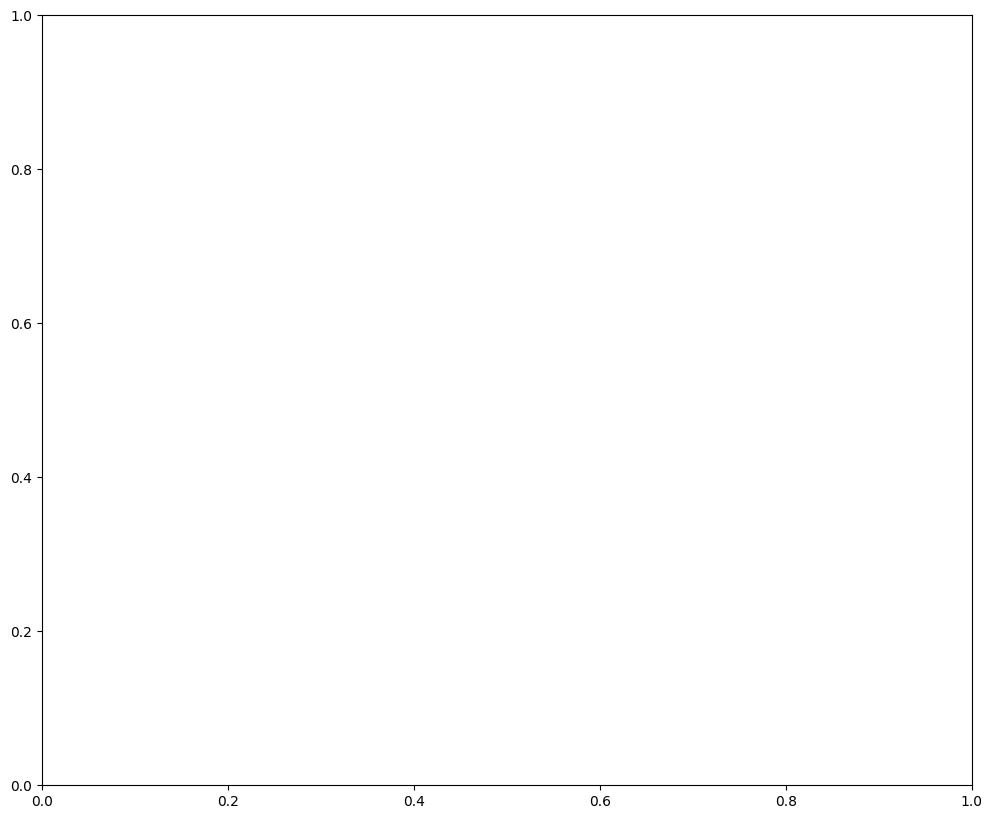

In [11]:
fig1, ax1 = plt.subplots(figsize=(12, 10))
scatter1 = ax1.scatter(umap_coords[:, 0], umap_coords[:, 1], 
                        c=cluster_labels_umap, cmap='tab20', 
                        s=2, alpha=1, edgecolors='none')
ax1.set_xlabel('UMAP 1', fontsize=12)
ax1.set_ylabel('UMAP 2', fontsize=12)
ax1.set_title(f'K-means Clustering (Clique {clique_id_analyze:02d}, {n_clusters_kmeans} clusters)', fontsize=14, fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='Cluster ID')
plt.tight_layout()
plt.show()
print(f"Saved: clique_{clique_id_analyze:02d}_kmeans_clusters_umap.pdf")

# Plot 2: GT neuron labels
print("\nPlotting GT neuron labels visualization...")
fig2, ax2 = plt.subplots(figsize=(12, 10))

# Get unique GT labels and assign colors
unique_gt_labels = sorted(set(gt_labels_umap))
n_unique = len(unique_gt_labels)
colors_gt = plt.cm.tab20(np.linspace(0, 1, min(n_unique, 20)))
if n_unique > 20:
    colors_gt = plt.cm.tab20(np.linspace(0, 1, 20))
    # Extend with additional colors if needed
    colors_gt = np.vstack([colors_gt, plt.cm.Set3(np.linspace(0, 1, n_unique - 20))])

label_to_color = {label: colors_gt[i % len(colors_gt)] for i, label in enumerate(unique_gt_labels)}

for label in unique_gt_labels:
    mask = gt_labels_umap == label
    ax2.scatter(umap_coords[mask, 0], umap_coords[mask, 1], 
                c=[label_to_color[label]], label=str(label),
                s=2, alpha=1, edgecolors='none')

ax2.set_xlabel('UMAP 1', fontsize=12)
ax2.set_ylabel('UMAP 2', fontsize=12)
ax2.set_title(f'GT Neuron Labels (Clique {clique_id_analyze:02d})', fontsize=14, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, markerscale=3, ncol=1)
plt.tight_layout()
plt.show()

In [ ]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
with open("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/clique_128/output/clique_01/model_save/run_1/calibration_results.pkl", 'rb') as f:
    a = pickle.load(f)

In [ ]:
results_df_simple = a['results_df_simple']
results_df_simple['gt_neuron_label_noise'] = results_df_simple['gt_neuron_label']
results_df_simple['predicted_neuron_label_noise'] = results_df_simple['predicted_neuron_label']
results_df_simple.loc[results_df_simple['gt_neuron_label'] == 'unmatch', 'gt_neuron_label_noise'] = 'noise'
results_df_simple.loc[results_df_simple['predicted_neuron_label'] == 'unmatch', 'predicted_neuron_label_noise'] = 'noise'
